bisection

In [ ]:
# Derivative F'(x) = -2x + 4
def df(x):
    return -2 * x + 4

#Bracket [a, b] containing root
a, b = 0.0, 3.0
tolerance = 1e-5

#looping each bisection
for step in range(20):
    c = (a + b) / 2.0                       #c is our midpoint and we want to make it become the maxima
    if df(c) == 0 or (b - a) < tolerance:
        break
    if df(c) * df(a) < 0:
        b = c
    else:
        a = c

In [ ]:
# Second Derivative F''(x) = -2
def d2f(x):
    return -2

In [ ]:
print(f"The estimated x-coordinate of the maximum is: {c}")
print(f"The final interval for x is: [{a}, {b}]")

The estimated x-coordinate of the maximum is: 2.0000009536743164
The final interval for x is: [1.9999980926513672, 2.0000038146972656]


Newton method

### Newton's Method for finding the maximum
To find the maximum of a function $F(x)$, we find the root of its derivative $F'(x) = 0$. Newton's method iteratively refines an estimate using the formula:

$x_{n+1} = x_n - \frac{F'(x_n)}{F''(x_n)}$

In our case, $F'(x) = -2x + 4$ and $F''(x) = -2$. Let's apply this method starting with an initial guess.

In [ ]:
# Initial guess
x0 = 0.0
tolerance = 1e-5

# Implement Newton's method
print(f"Starting Newton's method with initial guess: {x0}")

for i in range(20):
    df_x0 = df(x0)
    d2f_x0 = d2f(x0)

    # Avoid division by zero, though for this specific function d2f_x0 is constant -2
    if d2f_x0 == 0:
        print("Second derivative is zero, cannot proceed with Newton's method.")
        break

    x_new = x0 - (df_x0 / d2f_x0)

    print(f"Iteration {i+1}: x = {x_new:.6f}, F'(x) = {df_x0:.6f}")

    if abs(x_new - x0) < tolerance:
        print(f"Converged after {i+1} iterations.")
        break

    x0 = x_new

print(f"The estimated x-coordinate of the maximum using Newton's method is: {x0:.6f}")

Starting Newton's method with initial guess: 0.0
Iteration 1: x = 2.000000, F'(x) = 4.000000
Iteration 2: x = 2.000000, F'(x) = 0.000000
Converged after 2 iterations.
The estimated x-coordinate of the maximum using Newton's method is: 2.000000


### Multi-Start Newton's Method for a Complex Function
We will define a function with sinusoidal behavior and a single global maximum, then use Newton's method from multiple starting points to find it.

In [1]:
import numpy as np # Import numpy for numerical operations and arrays
import matplotlib.pyplot as plt # Import matplotlib for plotting

# Define the complex function F(x)
def F_complex(x):
    # A function with a global maximum and sinusoidal ripples
    return np.sin(5 * x) * np.exp(-0.2 * x**2) + 2 * np.exp(-0.5 * (x - 1)**2)

# Define the first derivative F'(x)
def dF_complex(x):
    # Derivative calculated using chain and product rules
    term1 = 5 * np.cos(5 * x) * np.exp(-0.2 * x**2) - 0.4 * x * np.sin(5 * x) * np.exp(-0.2 * x**2)
    term2 = -2 * (x - 1) * np.exp(-0.5 * (x - 1)**2)
    return term1 + term2

# Define the second derivative F''(x)
def d2F_complex(x):
    # Second derivative for Newton's method
    term1 = -25 * np.sin(5 * x) * np.exp(-0.2 * x**2) - 2 * np.cos(5 * x) * 0.4 * x * np.exp(-0.2 * x**2)
    term1 += -0.4 * np.sin(5 * x) * np.exp(-0.2 * x**2) + 0.16 * x**2 * np.sin(5 * x) * np.exp(-0.2 * x**2)
    term2 = -2 * np.exp(-0.5 * (x - 1)**2) + 2 * (x - 1)**2 * np.exp(-0.5 * (x - 1)**2)
    return term1 + term2

In [4]:
# Multi-start Newton's method setup
x_starts = np.linspace(-3, 4, 14) # Generate 8 starting points evenly spaced between -3 and 4. I had to increase this number to get better results.
tolerance = 1e-5 # Define the tolerance for convergence
max_iters = 50 # Maximum number of iterations per start

best_max_x = None # Variable to store the x-coordinate of the best maximum found
best_max_val = -float('inf') # Variable to store the highest function value found
all_paths = [] # List to store the search paths for visualization

for start_x in x_starts: # Iterate through each starting point
    x_curr = start_x # Set current x to the starting point
    path = [x_curr] # Initialize the path with the starting point

    for i in range(max_iters): # Loop for Newton iterations
        df_val = dF_complex(x_curr) # Calculate first derivative
        d2f_val = d2F_complex(x_curr) # Calculate second derivative

        if abs(d2f_val) < 1e-8: # Check to avoid division by zero
            break # Stop if second derivative is too close to zero

        x_new = x_curr - df_val / d2f_val # Apply Newton's update rule -- This dictates step size. Can be useful to use other algorithms for step size
        path.append(x_new) # Add the new x to the path

        if abs(x_new - x_curr) < tolerance: # Check for convergence
            break # Stop iterating if converged

        x_curr = x_new # Update current x for next iteration

    # Check if this converged point is a maximum (second derivative < 0)
    if d2F_complex(x_curr) < 0:
        val = F_complex(x_curr) # Evaluate function at the found point
        if val > best_max_val: # Check if it's the best maximum so far
            best_max_val = val # Update best maximum value
            best_max_x = x_curr # Update best maximum x-coordinate

    all_paths.append(path) # Store the path for plotting

print(f"Global maximum found at x = {best_max_x:.4f} with value {best_max_val:.4f}")

Global maximum found at x = 0.3519 with value 2.5794


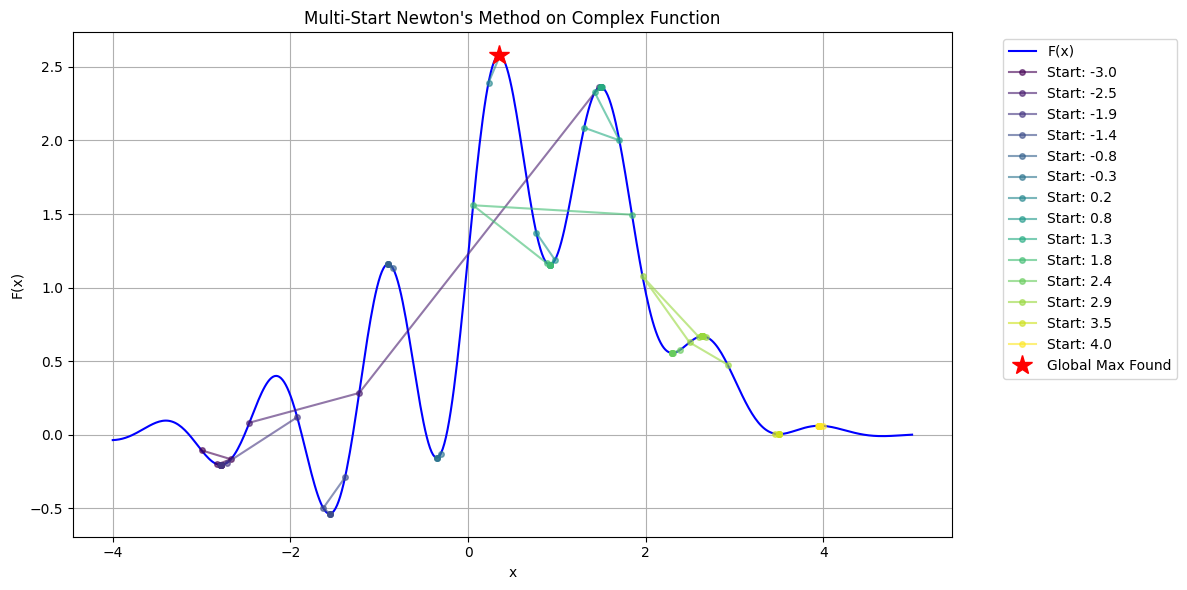

In [5]:
# Plotting the function and search paths
x_vals = np.linspace(-4, 5, 500) # Generate x values for plotting the function curve
y_vals = F_complex(x_vals) # Calculate y values for the function curve

plt.figure(figsize=(12, 6)) # Create a figure with specified size
plt.plot(x_vals, y_vals, label='F(x)', color='blue') # Plot the main function

# Plot the paths from each starting point
colors = plt.cm.viridis(np.linspace(0, 1, len(x_starts))) # Generate different colors for paths
for path, color, start in zip(all_paths, colors, x_starts): # Loop through paths and plot them
    y_path = [F_complex(x) for x in path] # Calculate y values for the path points
    plt.plot(path, y_path, marker='o', linestyle='-', color=color, alpha=0.6, markersize=4, label=f'Start: {start:.1f}') # Plot the path with markers

if best_max_x is not None: # Check if a valid maximum was found
    plt.plot(best_max_x, best_max_val, 'r*', markersize=15, label='Global Max Found') # Mark the global maximum with a red star

plt.title("Multi-Start Newton's Method on Complex Function") # Set plot title
plt.xlabel("x") # Set x-axis label
plt.ylabel("F(x)") # Set y-axis label
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Add legend outside the plot area
plt.grid(True) # Add grid lines
plt.tight_layout() # Adjust layout to fit legend
plt.show() # Display the plot